# Задача 1. Регрессия IC50

**Цель:** предсказать концентрацию, при которой соединение подавляет 50%
активности вируса гриппа

чем ниже IC50, тем сильнее противовирусный эффект
Модель, умеющая оценивать IC50 по структуре, позволяет отсеять заведомо слабые
кандидаты до синтеза и биологических испытаний

**Целевая переменная  log10(IC50), а не IC50.** Обоснование дано в EDA:
исходное распределение имеет асимметрию 3.67 и эксцесс 22.5, отношение
максимума к минимуму превышает 10^6. При обучении на исходной шкале функция
потерь MSE определялась бы десятком экстремальных объектов, а модель
фактически предсказывала бы «большое/не большое». Логарифмическая шкала —
отраслевой стандарт (pIC50) и делает ошибку сопоставимой по всему диапазону
концентраций

In [ ]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src import data_utils as du  # noqa: E402
from src import modeling as mdl  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path.cwd().parent / "reports" / "figures"
RES_DIR = Path.cwd().parent / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных

In [2]:
features, targets, groups, clean_report = du.load_dataset()
target = targets["log_ic50"]

print(f"Признаков: {features.shape[1]}, объектов: {features.shape[0]}")
print(f"Уникальных молекул (групп): {len(np.unique(groups))}")
print(f"\nЦелевая переменная: log10(IC50, mM)")
print(target.describe().round(3).to_string())

Признаков: 178, объектов: 1001
Уникальных молекул (групп): 804

Целевая переменная: log10(IC50, mM)
count    1001.000
mean        1.664
std         0.941
min        -2.454
25%         1.097
50%         1.668
75%         2.352
max         3.616


## 2. Разбиение на обучение и отложенный тест

Проверяем корректность разбиения: пересечение групп между train и test должно быть пустым, а распределения таргета сопоставимыми.

In [3]:
X_train, X_test, y_train, y_test, groups_train = mdl.group_train_test_split(
    features, target, groups
)
train_groups = set(groups[np.isin(features.index, X_train.index)])
test_groups = set(groups[np.isin(features.index, X_test.index)])

print(f"train: {X_train.shape[0]} объектов, {len(train_groups)} групп")
print(f"test:  {X_test.shape[0]} объектов, {len(test_groups)} групп")
print(f"Пересечение групп train/test: {len(train_groups & test_groups)}")

display(pd.DataFrame({
    "train": y_train.describe(),
    "test": y_test.describe(),
}).round(3))

train: 798 объектов, 643 групп
test:  203 объектов, 161 групп
Пересечение групп train/test: 0


,train,test
count,798.000,203.000
mean,1.642,1.748
std,0.936,0.958
min,-2.454,-1.875
25%,1.095,1.116
50%,1.635,1.829
75%,2.337,2.480
max,3.616,3.516


## 3. Подбор гиперпараметров и сравнение моделей

В эксперименте участвуют десять моделей разной природы. Это константный baseline, три линейные модели с различной регуляризацией, метрический метод kNN, ядровая SVR и четыре ансамбля деревьев, благодаря этому проще выбрать лучшую модель и понять какая именно зависимость скрыта в данных 
Качество моделей оценивается по R^2 на групповой кросс-валидации.

In [4]:
cv_table, fitted = mdl.search_candidates(
    mdl.regression_candidates(), X_train, y_train, groups_train,
    scoring="r2", task="ic50_reg",
)
display(cv_table.drop(columns=["комментарий"]).round(4))

Baseline (медиана)       CV r2 = -0.0104 (±0.0144)
Ridge                    CV r2 =  0.2243 (±0.0994)
Lasso                    CV r2 =  0.1907 (±0.0791)
ElasticNet               CV r2 =  0.1918 (±0.1004)
kNN                      CV r2 =  0.3992 (±0.1019)
SVR (RBF)                CV r2 =  0.3230 (±0.0856)


Random Forest            CV r2 =  0.3891 (±0.0941)


Extra Trees              CV r2 =  0.4023 (±0.0729)


LightGBM                 CV r2 =  0.3936 (±0.0888)
XGBoost                  CV r2 =  0.3672 (±0.1025)


,модель,CV r2,std,лучшие гиперпараметры,число обучений
0,Extra Trees,0.4023,0.0729,"{'max_depth': 22, 'max_features': 0.6, 'min_sa...",150
1,kNN,0.3992,0.1019,"{'n_neighbors': 23, 'p': 1, 'weights': 'distan...",150
2,LightGBM,0.3936,0.0888,"{'colsample_bytree': 0.4531, 'learning_rate': ...",150
3,Random Forest,0.3891,0.0941,"{'max_depth': 10, 'max_features': 0.3, 'min_sa...",150
4,XGBoost,0.3672,0.1025,"{'colsample_bytree': 0.59392, 'learning_rate':...",150
5,SVR (RBF),0.3230,0.0856,"{'C': 35.50013, 'epsilon': 0.45361, 'gamma': 0...",150
6,Ridge,0.2243,0.0994,{'alpha': 904.7072},150
7,ElasticNet,0.1918,0.1004,"{'alpha': 0.10907, 'l1_ratio': 0.20347}",150
8,Lasso,0.1907,0.0791,{'alpha': 0.04205},150
9,Baseline (медиана),-0.0104,0.0144,{},5


In [5]:
display(cv_table[["модель", "комментарий", "лучшие гиперпараметры"]]
        .set_index("модель"))

,комментарий,лучшие гиперпараметры
модель,,
Extra Trees,"усиленная рандомизация разбиений, меньше диспе...","{'max_depth': 22, 'max_features': 0.6, 'min_sa..."
kNN,"метрическая модель, проверка локальной структу...","{'n_neighbors': 23, 'p': 1, 'weights': 'distan..."
LightGBM,"градиентный бустинг, основной кандидат на лучш...","{'colsample_bytree': 0.4531, 'learning_rate': ..."
Random Forest,"бэггинг деревьев, устойчив к переобучению и ко...","{'max_depth': 10, 'max_features': 0.3, 'min_sa..."
XGBoost,альтернативная реализация бустинга для перекрё...,"{'colsample_bytree': 0.59392, 'learning_rate':..."
SVR (RBF),"нелинейная модель на ядре, устойчива при высок...","{'C': 35.50013, 'epsilon': 0.45361, 'gamma': 0..."
Ridge,линейная модель с L2-регуляризацией,{'alpha': 904.7072}
ElasticNet,"компромисс L1/L2, устойчив к мультиколлинеарности","{'alpha': 0.10907, 'l1_ratio': 0.20347}"
Lasso,L1: одновременно выполняет отбор признаков,{'alpha': 0.04205}


## 4. Оценка на отложенном тесте

Модели дообучились на всей обучающей выборке с оптимальными гиперпараметрами и применили к тестовой части, которая до этого не участвовала в процессе. Основная метрика R^2 Дополнительно считаем две химически метрики RMSE (log10) и медианная ошибка

In [6]:
test_table = mdl.evaluate_on_test(fitted, X_test, y_test, task="regression")
display(test_table.round(3))
test_table.to_csv(RES_DIR / "ic50_reg_test_metrics.csv", index=False)

,модель,R2,RMSE (log10),MAE (log10),MedAE (исх. ед.),"медианная ошибка, раз"
0,LightGBM,0.501,0.675,0.538,49.862,2.708
1,Extra Trees,0.500,0.676,0.535,46.116,2.839
2,Random Forest,0.483,0.687,0.554,50.438,3.035
3,kNN,0.447,0.711,0.575,47.318,2.981
4,XGBoost,0.438,0.716,0.585,59.868,3.199
5,SVR (RBF),0.426,0.724,0.571,62.426,3.060
6,Lasso,0.140,0.886,0.703,51.103,4.424
7,Baseline (медиана),-0.014,0.962,0.775,42.741,4.713
8,Ridge,-0.016,0.963,0.705,55.437,4.170
9,ElasticNet,-0.209,1.051,0.721,58.378,4.148


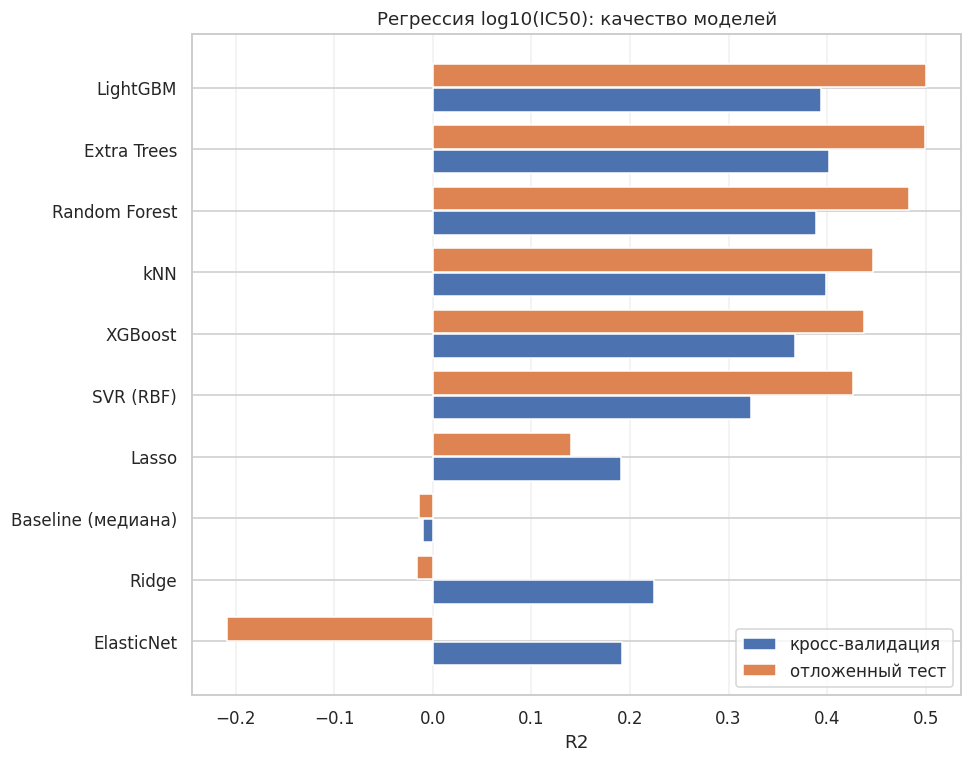

In [7]:
mdl.plot_cv_vs_test(
    cv_table, test_table, "CV r2", "R2",
    "Регрессия log10(IC50): качество моделей",
    save_path=FIG_DIR / "ic50_reg_models_comparison.png",
)

## 5. Диагностика лучшей модели

Три графика отвечают на  вопросы: есть ли систематическое смещение прогноза, однородна ли ошибка по диапазону значений, нормальны ли остатки

Лучшая модель на тесте: LightGBM


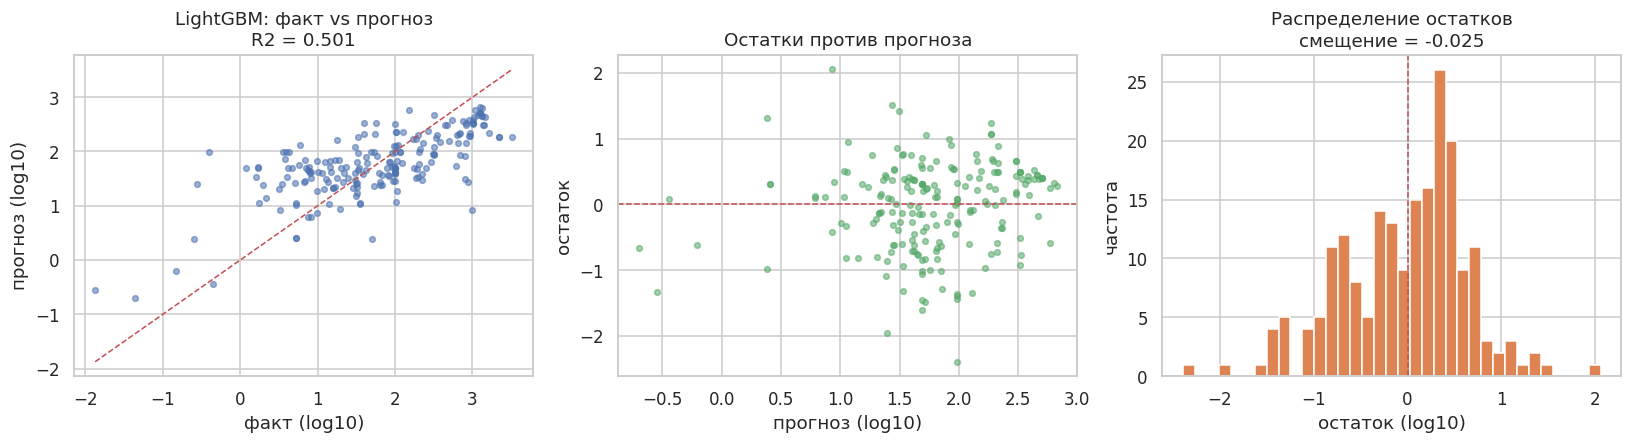

In [8]:
best_name = test_table.iloc[0]["модель"]
best_model = fitted[best_name]
print(f"Лучшая модель на тесте: {best_name}")

predictions = best_model.predict(X_test)
mdl.plot_regression_diagnostics(
    y_test.to_numpy(), predictions, best_name,
    save_path=FIG_DIR / "ic50_reg_diagnostics.png",
)

In [9]:
errors = pd.DataFrame({
    "факт": y_test.to_numpy(),
    "прогноз": predictions,
    "остаток": y_test.to_numpy() - predictions,
})
quartiles = pd.qcut(errors["факт"], 4,
                    labels=["Q1 (низкие)", "Q2", "Q3", "Q4 (высокие)"])
print("Средний остаток и MAE по квартилям истинного значения:")
display(errors.groupby(quartiles)["остаток"].agg(
    смещение="mean", MAE=lambda s: s.abs().mean(), объектов="size").round(3))

Средний остаток и MAE по квартилям истинного значения:


,смещение,MAE,объектов
факт,,,
Q1 (низкие),-0.799,0.841,51
Q2,-0.139,0.360,51
Q3,0.259,0.353,50
Q4 (высокие),0.586,0.593,51


## 6. дескрипторы определяющие прогноз

Используется permutation importance на отложенном тесте: признак перемешивается и измеряеться падение R^2

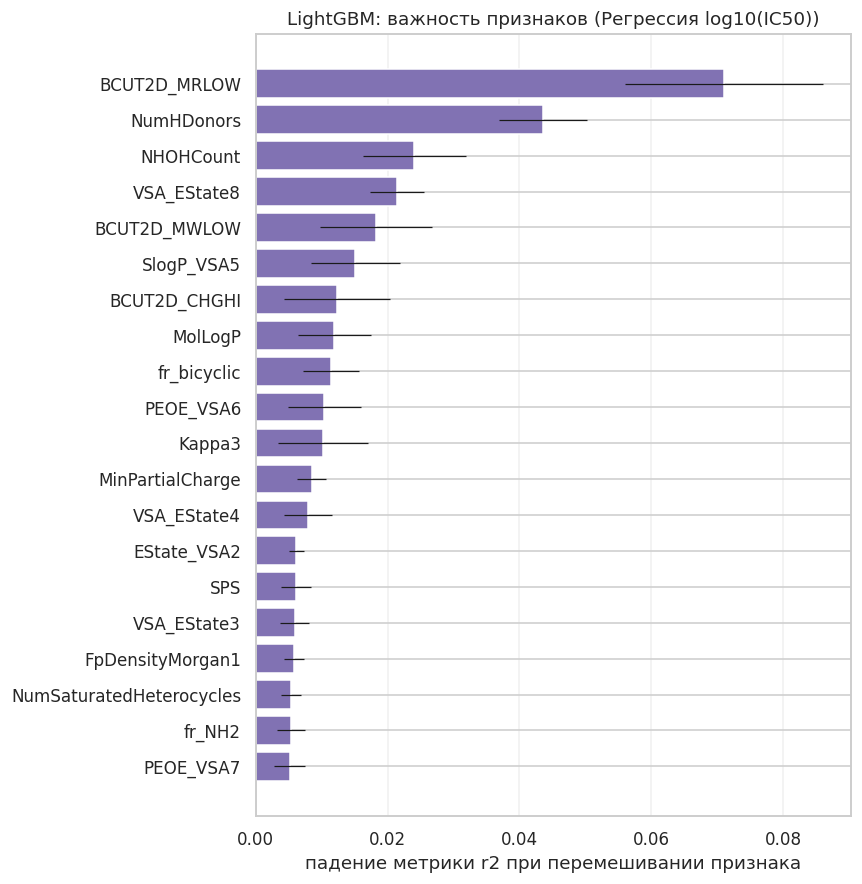

,признак,падение качества,std
0,BCUT2D_MRLOW,0.0710,0.0150
1,NumHDonors,0.0436,0.0067
2,NHOHCount,0.0241,0.0078
3,VSA_EState8,0.0215,0.0041
4,BCUT2D_MWLOW,0.0183,0.0085
5,SlogP_VSA5,0.0151,0.0067
6,BCUT2D_CHGHI,0.0123,0.0080
7,MolLogP,0.0120,0.0055
8,fr_bicyclic,0.0114,0.0043
9,PEOE_VSA6,0.0104,0.0056


In [10]:
importance = mdl.plot_permutation_importance(
    best_model, X_test, y_test, scoring="r2",
    title=f"{best_name}: важность признаков (Регрессия log10(IC50))",
    save_path=FIG_DIR / "ic50_reg_importance.png",
)
display(importance.head(15).round(4))
importance.to_csv(RES_DIR / "ic50_reg_importance.csv", index=False)

## 7. Устойчивость результата

Одно разбиение train/test даёт лишь точечную оценку. Повторяем обучение и измерение на пяти независимых групповых разбиениях, чтобы понять, насколько приведённые цифры воспроизводимы

In [11]:
from sklearn.metrics import r2_score

stability = mdl.stability_check(
    best_model, features, target, groups,
    scoring=lambda y_true, model, X: r2_score(y_true, model.predict(X)),
)
display(stability.round(4))

Среднее = 0.4353, std = 0.0716, размах = 0.1911


,seed,метрика
0,0,0.3521
1,1,0.4152
2,2,0.5432
3,3,0.4607
4,4,0.4056


## 8. Выводы по задаче регрессии IC50
(красивую табилцу попросил у дипсика сделать , каюсь, зато приятнее для понимания)
### Что показали модели

| Наблюдение | Интерпретация |
|---|---|
| Лучший результат — ансамбли деревьев (Extra Trees, LightGBM, Random Forest), CV R² ≈ 0.39–0.40, на тесте R² ≈ 0.48–0.50 | Задача решаема, но зависимость существенно нелинейна |
| Линейные модели (Ridge, Lasso, ElasticNet) дают CV R² ≈ 0.19–0.22, а на отложенном тесте Ridge и ElasticNet опускаются ниже нуля | Линейной составляющей в данных почти нет; согласуется с выводом EDA о максимальной корреляции признака с таргетом 0.28. Отрицательный R² на тесте показывает, что линейная модель здесь неустойчива и подбирает регуляризацию под конкретный фолд |
| kNN неожиданно силён (CV R² ≈ 0.40) | В пространстве дескрипторов близкие молекулы действительно имеют близкую активность — это подтверждает базовую гипотезу QSAR и говорит о локальной, а не глобальной структуре зависимости |
| Extra Trees устойчиво обходит Random Forest | Дополнительная рандомизация порогов разбиения снижает дисперсию — полезно при сильно коррелированных признаках, каких у нас 84 пары |
| Разрыв между CV (0.40) и тестом (0.50) | Отложенная выборка оказалась «удобнее» средней. Ориентироваться следует на **CV-оценку** как более консервативную; проверка устойчивости на пяти разбиениях даёт разброс R² около ±0.07 |

### Точность

Медианная ошибка лучшей модели примерно в 2.7–2.8 раза по концентрации
- Для скрининга это приемлемо, модель уверенно разделяет соединения, различающиеся на порядок, но не может заменить измерение при выборе между двумя близкими кандидатами.

### Рекомендация

Для промышленного использования выбираем Extra Trees он лидирует по :
кросс-валидации, практически не уступает LightGBM на тесте, обучается быстрее
бустинга и имеет меньше гиперпараметров, критичных к настройке. LightGBM разумная альтернатива, если важна скорость предсказания

### Улучшения

- добавить структурную информацию RDKit-дескрипторы дают интегральную картину, но теряют взаимное расположение фрагментов. Молекулярные отпечатки (Morgan, ECFP) или графовые нейросети обычно дают ощутимый прирост в QSAR и здесь могут стать ключевым улучшением

- увеличить объём данных. Сейчас у нас 804 уникальные молекулы и 178 признаков. Модель упирается в ограниченность выборки. Добавление публичных данных по тому же вирусу может улучшить качество
